# HSC and DESI Data Encoding with AION

This notebook demonstrates batched loading of HSC and DESI data, encoding using AION codecs, and visualizing embeddings with UMAP.

## Imports and Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from aion import AION
from aion.codecs import CodecManager
from aion.datasets import HSCDataset, DESIDataset
from umap.umap_ import UMAP

CACHE_DIR = "../data/"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Load Datasets with Batching

In [2]:
BATCH_SIZE = 1
BATCH_COUNT = 2

print("Loading HSC dataset...")
hsc_dataset = HSCDataset(
    cache_dir=CACHE_DIR,
    batch_size=BATCH_SIZE,
    batch_count=BATCH_COUNT,
    device=device
)

print("\nLoading DESI dataset...")
desi_dataset = DESIDataset(
    cache_dir=CACHE_DIR,
    batch_size=BATCH_SIZE,
    batch_count=BATCH_COUNT,
    device=device
)

print(f"\nTotal HSC samples: {len(hsc_dataset)}")
print(f"Total DESI samples: {len(desi_dataset)}")

Loading HSC dataset...
Loaded 2 samples from disk: ../data/hsc_slice

Loading DESI dataset...
Loaded 2 samples from disk: ../data/desi_slice

Total HSC samples: 2
Total DESI samples: 2


## Initialize AION Model and Codec Manager

In [3]:
print("Loading AION model...")
model = AION.from_pretrained('polymathic-ai/aion-base').to(device)
print("Loading Codec Manager...")
codec_manager = CodecManager(device=device)
print("Model and codec manager loaded successfully")

Loading AION model...
Loading Codec Manager...
Model and codec manager loaded successfully


## Process HSC and DESI Together: Encode → Embed → Mean Average

In [4]:
print("Processing HSC and DESI batches together...")
all_embeddings_list = []

for i, (hsc_batch, desi_batch) in enumerate(zip(hsc_dataset, desi_dataset)):
    print(f"\nBatch {i+1}/{BATCH_COUNT}")
    print(f"  HSC: {hsc_batch.flux.shape}")
    print(f"  DESI: {desi_batch.flux.shape}")
    
    # Encode both modalities together
    tokens = codec_manager.encode(hsc_batch, desi_batch)
    print(f"    HSC tokens: {tokens['tok_image_hsc'].shape}")
    print(f"    DESI tokens: {tokens['tok_spectrum_desi'].shape}")
    
    # Generate embeddings from combined tokens
    embeddings = model.encode(tokens)
    print(f"    Combined embeddings shape: {embeddings.shape}")
    
    # Mean average over sequence length (dim=1)
    avg_embeddings = embeddings.mean(dim=1)
    print(f"    Averaged shape: {avg_embeddings.shape}")
    
    all_embeddings_list.append(avg_embeddings.cpu().detach())

# Concatenate all batches
all_embeddings = torch.cat(all_embeddings_list, dim=0).numpy()
print(f"\nFinal combined embeddings shape: {all_embeddings.shape}")
print(f"Total samples: {all_embeddings.shape[0]} (HSC+DESI pairs)")

Processing HSC and DESI batches together...

Batch 1/2
  HSC: torch.Size([1, 5, 160, 160])
  DESI: torch.Size([1, 7781])
    HSC tokens: torch.Size([1, 576])
    DESI tokens: torch.Size([1, 273])
    Combined embeddings shape: torch.Size([1, 256, 768])
    Averaged shape: torch.Size([1, 768])

Batch 2/2
  HSC: torch.Size([1, 5, 160, 160])
  DESI: torch.Size([1, 7781])
    HSC tokens: torch.Size([1, 576])
    DESI tokens: torch.Size([1, 273])
    Combined embeddings shape: torch.Size([1, 256, 768])
    Averaged shape: torch.Size([1, 768])

Final combined embeddings shape: (2, 768)
Total samples: 2 (HSC+DESI pairs)


## UMAP Visualization

In [5]:
# all_embeddings already created in previous cell (combined HSC+DESI)

print(f"Total embeddings shape: {all_embeddings.shape}")
print(f"Samples: {all_embeddings.shape[0]} HSC+DESI pairs")

# Apply UMAP for 2D visualization
print("\nApplying UMAP for 2D visualization...")
reducer = UMAP(n_components=2, random_state=42, n_neighbors=5)
embeddings_2d = reducer.fit_transform(all_embeddings)

print(f"UMAP reduced shape: {embeddings_2d.shape}")

# Visualize
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    #c=range(len(embeddings_2d)),
    cmap='viridis',
    alpha=0.7,
    s=150
)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.title('UMAP Visualization of Combined HSC+DESI Embeddings', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOriginal embedding dimension: {all_embeddings.shape[1]}")
print(f"UMAP reduced dimension: {embeddings_2d.shape[1]}")

Total embeddings shape: (2, 768)
Samples: 2 HSC+DESI pairs

Applying UMAP for 2D visualization...


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(
/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/umap/umap_.py:134: UserWarning: A large number of your vertices were disconnected from the manifold.
Disconnection_distance = inf has removed 0 edges.
It has fully disconnected 2 vertices.
You might consider using find_disconnected_points() to find and remove these points from your data.
Use umap.utils.disconnected_vertices() to identify them.
  warn(


ValueError: zero-size array to reduction operation maximum which has no identity

# DECODE




In [8]:
from aion.modalities import HSCImage, DESISpectrum, EuclidImage
from aion.codecs.preprocessing.image import (
    ImagePadder,
    CenterCrop,
    RescaleToLegacySurvey,
    Clamp,
)


entry = 0
hsc_batch = hsc_dataset[1]

tokens = codec_manager.encode(hsc_batch)

reconstructed_image = codec_manager.decode(
    tokens,
    HSCImage,  # The modality from the 'tokens' dictionary we want to decode
    bands=hsc_batch.bands,
)  # Metadata required to reconstruct the given modality

hsc_batch = hsc_dataset[1]

rescaler = RescaleToLegacySurvey()

rescaled_original = rescaler.forward(hsc_batch.flux , survey="HSC")


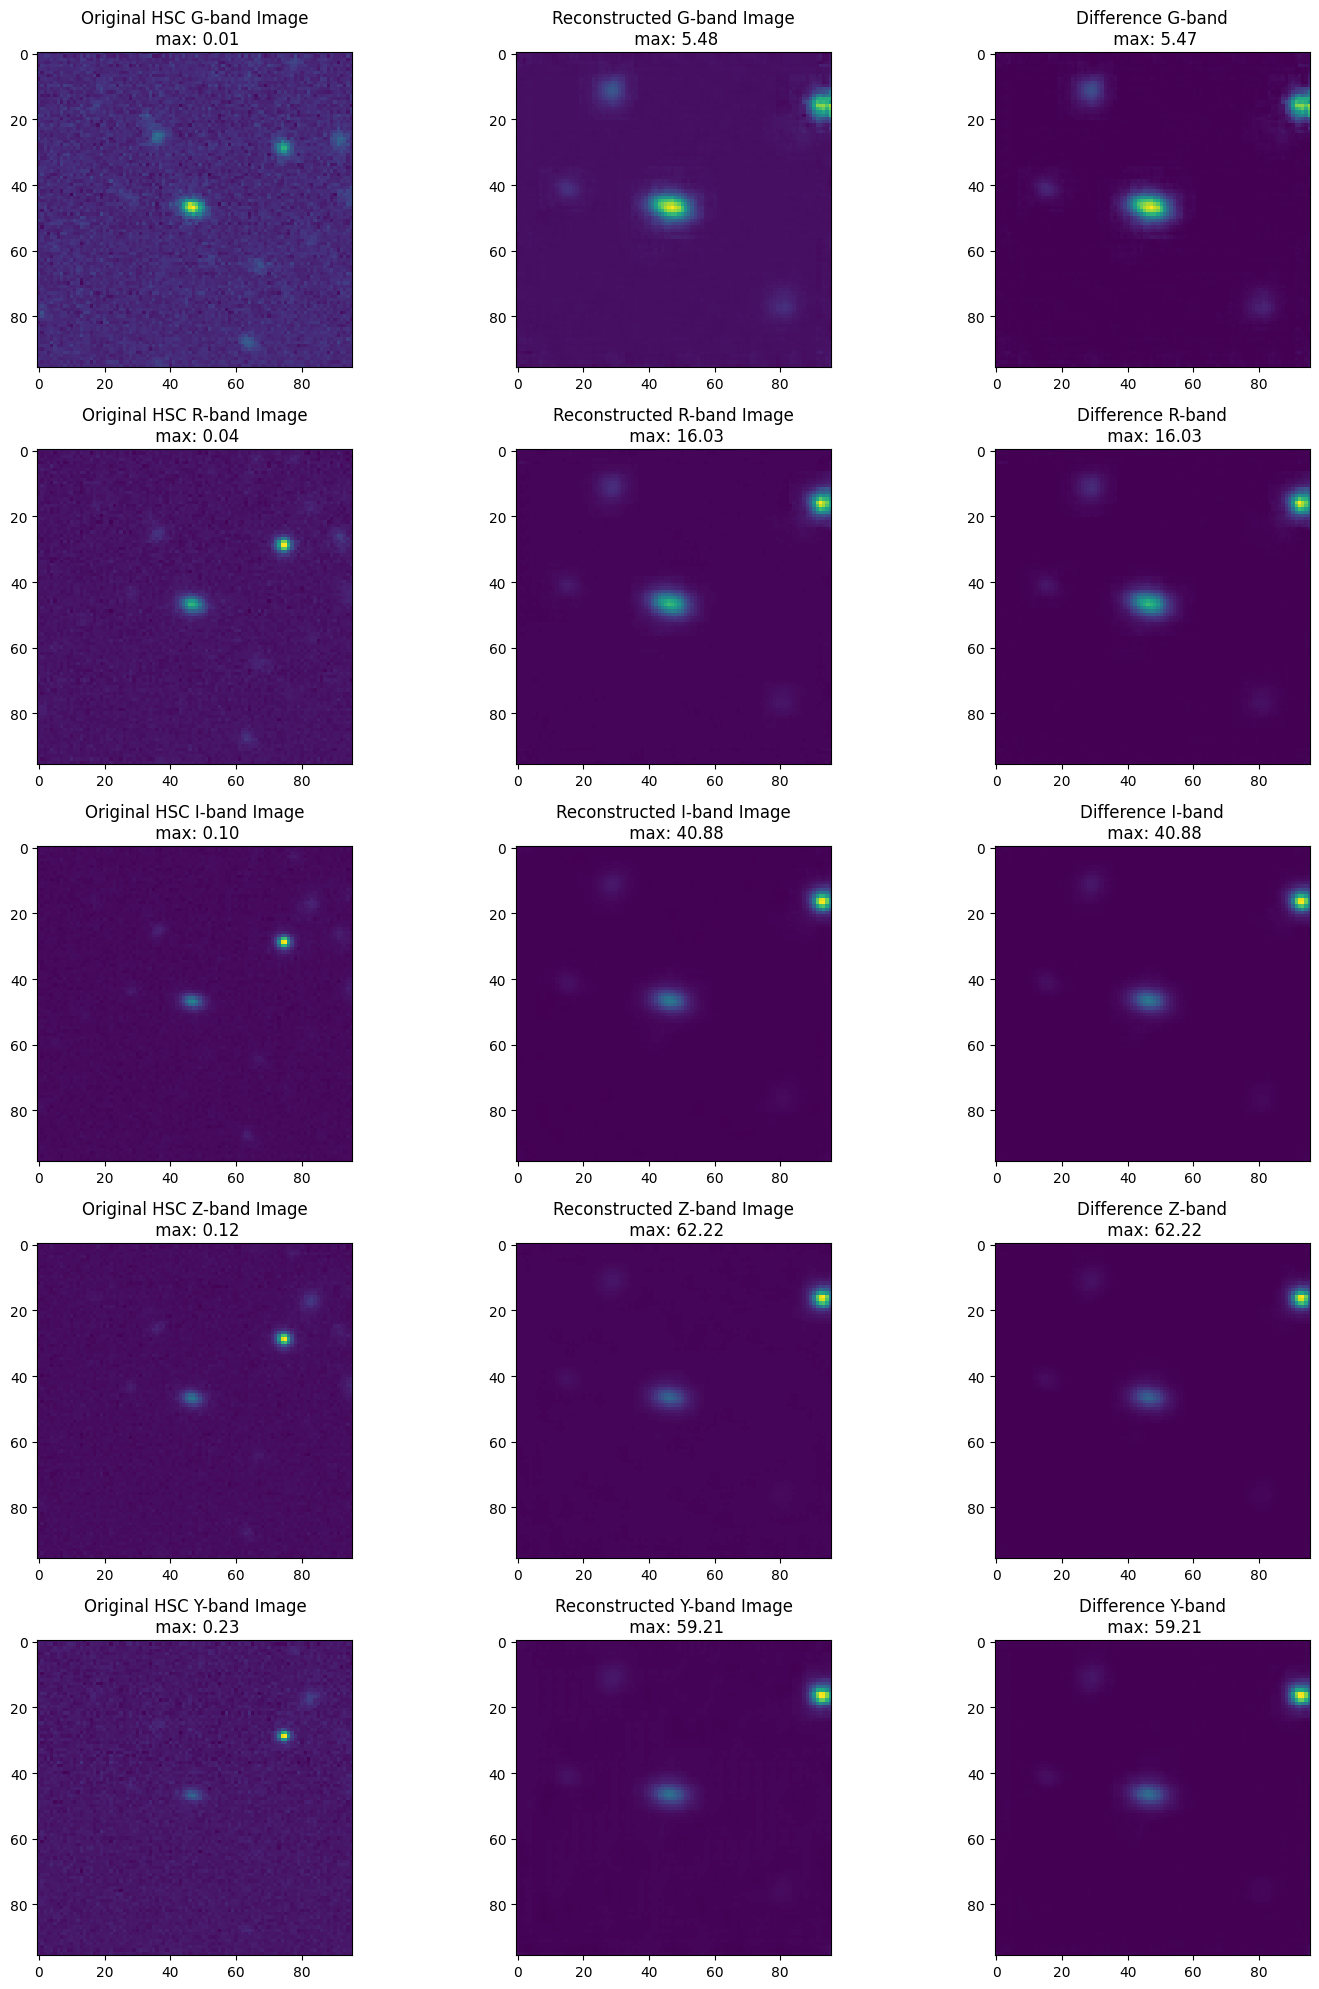

: 

In [ ]:
from torch.nn.functional import interpolate

figure, axes = plt.subplots(5, 3, figsize=(15, 20))

# interpolate original to reconstructed size
original_images = []
reconstructed = []
differences = []
for i in range(5):
    original_image_resized = interpolate(
        rescaled_original[:, i:i+1, :, :],
        size=reconstructed_image.flux.shape[2:],
        mode='bilinear',
        align_corners=False
    )
    original_image_resized = original_image_resized[0 , 0]
    reconstructed_image_tensor = reconstructed_image.flux[0 , i, :, :]
    original_images.append(original_image_resized.cpu().detach().numpy())
    reconstructed.append(reconstructed_image_tensor.cpu().detach().numpy())
    differences.append(torch.abs(reconstructed_image_tensor - original_image_resized).cpu().detach().numpy())

bands = ['G', 'R', 'I', 'Z', 'Y']

for i in range(5):
    # Column 0: Original
    axes[i, 0].imshow(original_images[i])
    axes[i, 0].set_title(f"Original HSC {bands[i]}-band Image\n max: {original_images[i].max():.2f}")
    
    # Column 1: Reconstructed
    axes[i, 1].imshow(reconstructed[i])
    axes[i, 1].set_title(f"Reconstructed {bands[i]}-band Image\n max: {reconstructed[i].max():.2f}")
    
    # Column 2: Difference
    axes[i, 2].imshow(differences[i])
    axes[i, 2].set_title(f"Difference {bands[i]}-band\n max: {differences[i].max():.2f}")

plt.tight_layout()
plt.show()


# CROSS


In [ ]:
from aion.modalities import HSCImage, DESISpectrum, EuclidImage

entry = 1
hsc_batch = hsc_dataset[entry]
desi_batch = desi_dataset[entry]

tokens = codec_manager.encode(hsc_batch , desi_batch)

reconstructed_image = codec_manager.decode(
    tokens,
    HSCImage,  # The modality from the 'tokens' dictionary we want to decode
    bands=hsc_batch.bands,
)  # Metadata required to reconstruct the given modality

hsc_batch = hsc_dataset[entry]
desi_batch = desi_dataset[entry]

logits_images = model(tokens , target_modality=DESISpectrum)

token_key = DESISpectrum.token_key
pred_token = {token_key: logits_images[token_key].softmax(dim=-1).argmax(dim=-1)}

generated_desi = codec_manager.decode(
    pred_token,
    DESISpectrum,
    wavelength=desi_batch.wavelength,
)


In [ ]:
desi_batch.flux[0] - generated_desi.flux[0]

tensor([  4.5389, -11.1689,   3.7519,  ...,  -0.4691,  -1.3031,  -0.4334])

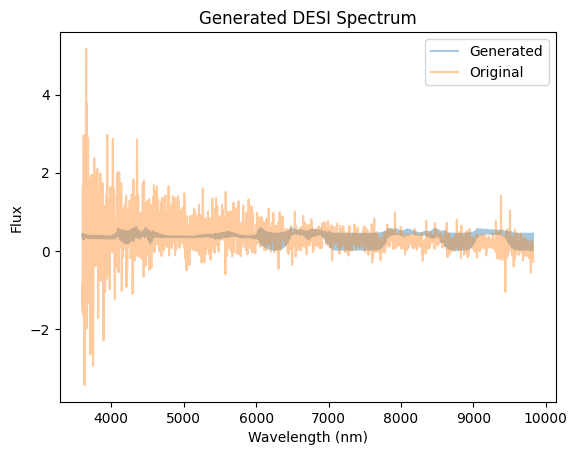

In [ ]:
from scipy.ndimage import gaussian_filter1d

w = generated_desi.wavelength[0].cpu().detach().numpy()
f = gaussian_filter1d(generated_desi.flux[0].cpu().detach().numpy() , 2)
o = gaussian_filter1d(desi_batch.flux[0].cpu().detach().numpy() , 2)

plt.plot(w, f, label="Generated" , alpha=0.4)
plt.plot(w, o, label="Original" , alpha=0.4)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Flux")
plt.legend()
plt.title("Generated DESI Spectrum")
plt.show()